# Exploratory Data Analysis (EDA)

## Objective

The objective of Exploratory Data Analysis (EDA) is to understand the trading dataset through visualizations and summary statistics. This analysis helps identify hidden patterns, relationships between variables, and potential factors influencing trader profitability before building machine learning models.

In [4]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
# Load cleaned dataset
bitcoin_data = pd.read_csv("cleaned_bitcoin_data.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
bitcoin_data.head()

,fead39b70a1824f981a54d4e55b278e9f760,BTC,100290.0,0.00066,66.19,BUY,2024-06-12 00:30:00,-5.46786,Close Short,0.38082,...,1730000000000.0,2024-06-12,1718170200.0,72.0,Greed,1,0,Wednesday,0.1,3.0
0,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,100290.0,5.46720,548305.49,BUY,2024-06-12 00:30:00,-5.46720,Close Short,3154.5744,...,1.730000e+12,2024-06-12,1.718170e+09,72.0,Greed,1,0,Wednesday,0,3.0
1,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,100440.0,0.00100,100.44,BUY,2024-06-12 00:31:00,0.00000,Open Long,0.0000,...,1.730000e+12,2024-06-12,1.718170e+09,72.0,Greed,0,0,Wednesday,0,3.0
2,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,100440.0,0.19817,19904.19,BUY,2024-06-12 00:31:00,0.00100,Open Long,0.0000,...,1.730000e+12,2024-06-12,1.718170e+09,72.0,Greed,0,0,Wednesday,0,3.0
3,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,99701.0,0.39846,39726.86,BUY,2024-06-12 01:14:00,0.19917,Open Long,0.0000,...,1.730000e+12,2024-06-12,1.718170e+09,72.0,Greed,0,1,Wednesday,0,3.0
4,0x4f93fead39b70a1824f981a54d4e55b278e9f760,BTC,98940.0,0.60662,60018.98,BUY,2024-06-12 01:26:00,0.59763,Open Long,0.0000,...,1.730000e+12,2024-06-12,1.718170e+09,72.0,Greed,0,1,Wednesday,0,3.0


In [ ]:
bitcoin_data.tail()

,fead39b70a1824f981a54d4e55b278e9f760,BTC,100290.0,0.00066,66.19,BUY,2024-06-12 00:30:00,-5.46786,Close Short,0.38082,...,1730000000000.0,2024-06-12,1718170200.0,72.0,Greed,1,0,Wednesday,0.1,3.0
146904,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,2025-04-25 15:35:00,7546.6,Close Long,-20.2566,...,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,0,15,Friday,0,3.0
146905,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,2025-04-25 15:35:00,7164.4,Close Long,-112.5773,...,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,0,15,Friday,0,3.0
146906,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,2025-04-25 15:35:00,5040.3,Close Long,-22.4402,...,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,0,15,Friday,0,3.0
146907,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,2025-04-25 15:35:00,4616.9,Close Long,-190.7894,...,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,0,15,Friday,0,3.0
146908,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,2025-04-25 15:35:00,1017.1,Close Long,-53.9063,...,1.750000e+12,2025-04-25,1.745559e+09,60.0,Greed,0,15,Friday,0,3.0


In [9]:
print("Rows :", bitcoin_data.shape[0])
print("Columns :",bitcoin_data.shape[1])

Rows : 167857
Columns : 25


In [10]:
bitcoin_data.describe()

,execution_price,size_tokens,size_usd,start_position,closed_pnl,order_id,fee,trade_id,timestamp_x,timestamp_y,value,profit_flag,hour,is_weekend,sentiment_score
count,167857.000000,1.678570e+05,1.678570e+05,1.678570e+05,167857.000000,1.678570e+05,167857.000000,1.678570e+05,1.678570e+05,1.678570e+05,167857.000000,167857.00000,167857.000000,167857.000000,167857.000000
mean,10917.135406,5.116982e+03,5.389755e+03,-4.322903e+04,48.853074,6.759207e+10,1.095066,5.623287e+14,1.737162e+12,1.737330e+09,54.698547,0.40970,11.547549,0.225877,2.352330
std,29008.228358,1.133575e+05,3.699618e+04,7.271133e+05,853.621489,1.973031e+10,6.820286,3.257258e+14,9.662754e+09,8.980998e+06,20.253089,0.49178,7.247940,0.418160,1.181169
min,0.000005,2.390000e-06,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12,1.672897e+09,10.000000,0.00000,0.000000,0.000000,0.000000
25%,4.243900,3.000000e+00,1.778500e+02,-6.179100e+02,0.000000,5.654734e+10,0.015122,2.800000e+14,1.730000e+12,1.734586e+09,37.000000,0.00000,5.000000,0.000000,1.000000
50%,19.039000,3.030000e+01,5.632000e+02,5.340682e+01,0.000000,7.328153e+10,0.086361,5.620000e+14,1.740000e+12,1.740116e+09,54.000000,0.00000,12.000000,0.000000,2.000000
75%,30.423000,1.804100e+02,2.014430e+03,8.128972e+03,5.340160,8.233002e+10,0.372278,8.450000e+14,1.740000e+12,1.743399e+09,73.000000,1.00000,19.000000,0.000000,3.000000
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,115287.000000,9.014923e+10,837.471593,1.130000e+15,1.750000e+12,1.746164e+09,94.000000,1.00000,23.000000,1.000000,4.000000


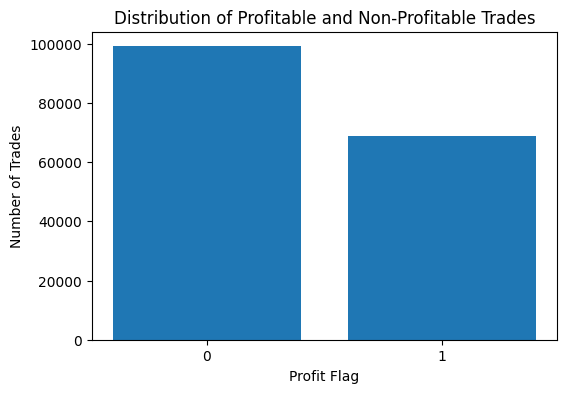

In [12]:
#Profit Distribution
profit_counts = bitcoin_data["profit_flag"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    profit_counts.index.astype(str),
    profit_counts.values
)

plt.title("Distribution of Profitable and Non-Profitable Trades")

plt.xlabel("Profit Flag")

plt.ylabel("Number of Trades")

plt.show()

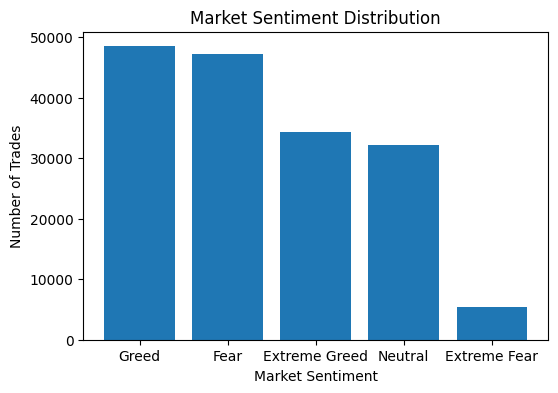

In [13]:
#Market Sentiment Distribution
sentiment_counts = bitcoin_data["classification"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Market Sentiment Distribution")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trades")

plt.show()

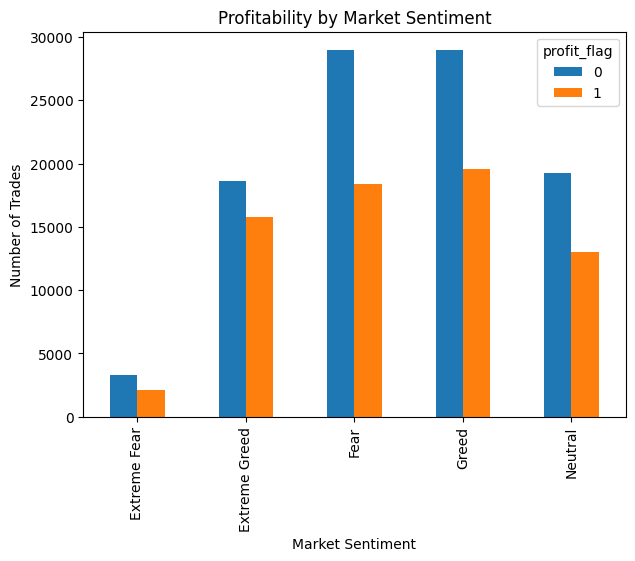

In [14]:
#Profit by Market Sentiment
profit_sentiment = pd.crosstab(
    bitcoin_data["classification"],
    bitcoin_data["profit_flag"]
)

profit_sentiment.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Profitability by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Number of Trades")

plt.show()

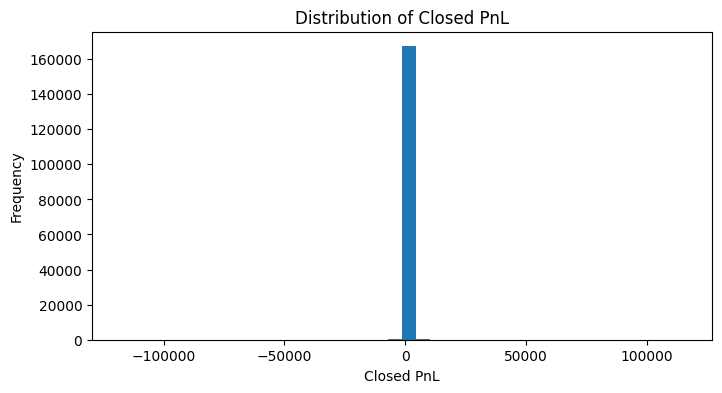

In [16]:
#Closed Pnl Distribution
plt.figure(figsize=(8,4))

plt.hist(
    bitcoin_data["closed_pnl"],
    bins=40
)

plt.title("Distribution of Closed PnL")

plt.xlabel("Closed PnL")

plt.ylabel("Frequency")

plt.show()

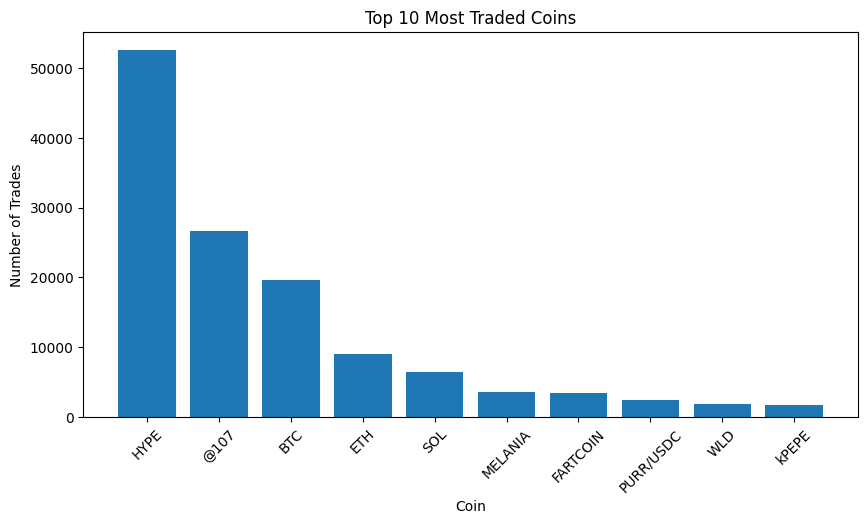

In [17]:
#Top 10 Traded Coins
top_coins = bitcoin_data["coin"].value_counts().head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_coins.index,
    top_coins.values
)

plt.xticks(rotation=45)

plt.title("Top 10 Most Traded Coins")

plt.xlabel("Coin")

plt.ylabel("Number of Trades")

plt.show()

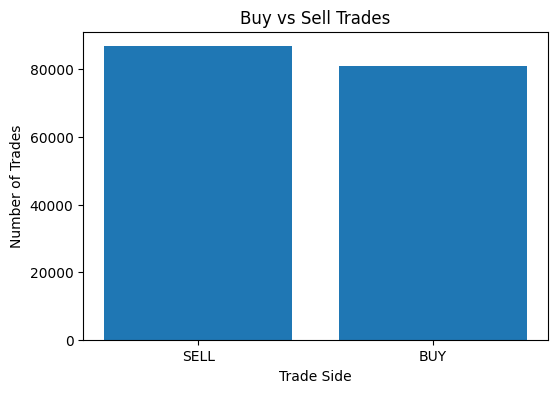

In [18]:
#Buy vs Sell Trades
side_counts = bitcoin_data["side"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    side_counts.index,
    side_counts.values
)

plt.title("Buy vs Sell Trades")

plt.xlabel("Trade Side")

plt.ylabel("Number of Trades")

plt.show()

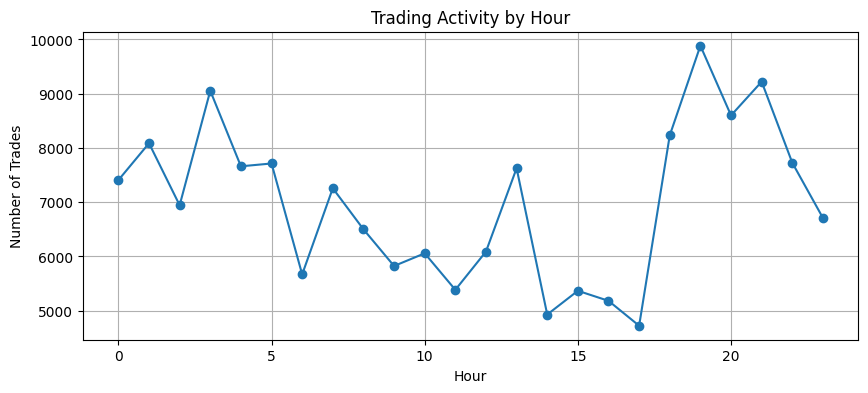

In [21]:
#Trading Activity by Hour
hour_counts = bitcoin_data["hour"].value_counts().sort_index()

plt.figure(figsize=(10,4))

plt.plot(
    hour_counts.index,
    hour_counts.values,
    marker="o"
)

plt.title("Trading Activity by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Trades")

plt.grid(True)

plt.show()

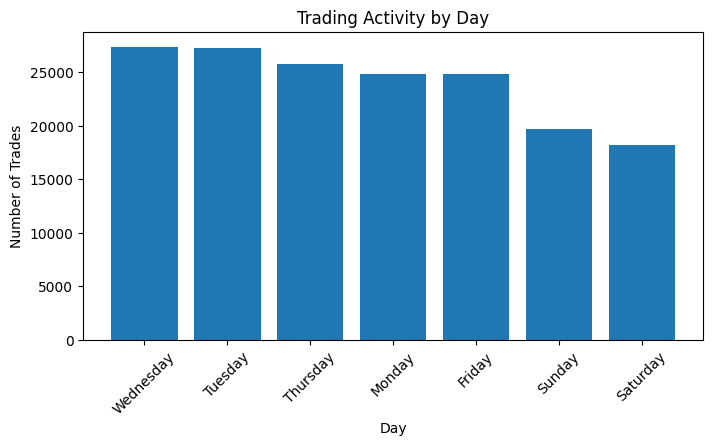

In [23]:
#Trading Activity by Day
day_counts = bitcoin_data["day_of_week"].value_counts()

plt.figure(figsize=(8,4))

plt.bar(
    day_counts.index,
    day_counts.values
)

plt.xticks(rotation=45)

plt.title("Trading Activity by Day")

plt.xlabel("Day")

plt.ylabel("Number of Trades")

plt.show()

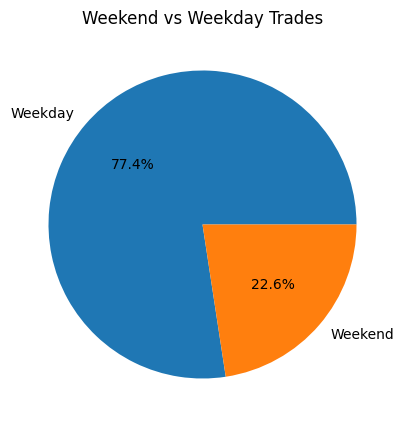

In [24]:
#Weekend vs Weekday
weekend_counts = bitcoin_data["is_weekend"].value_counts()

labels = ["Weekday", "Weekend"]

plt.figure(figsize=(5,5))

plt.pie(
    weekend_counts.values,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Weekend vs Weekday Trades")

plt.show()

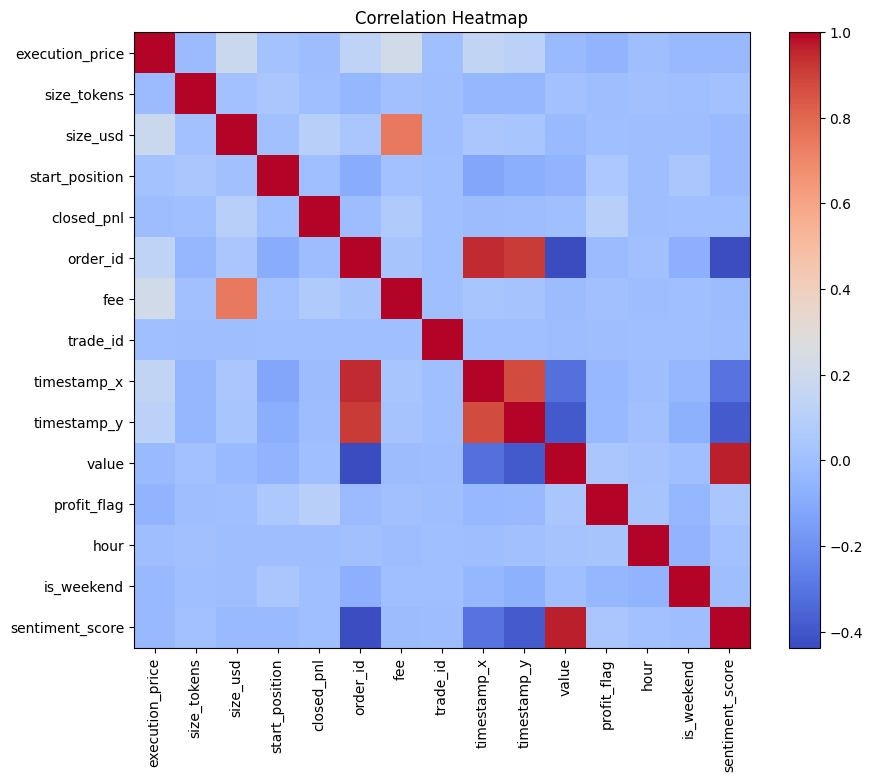

In [25]:
#Correlation Heatmap
corr = bitcoin_data.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,8))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Heatmap")

plt.show()

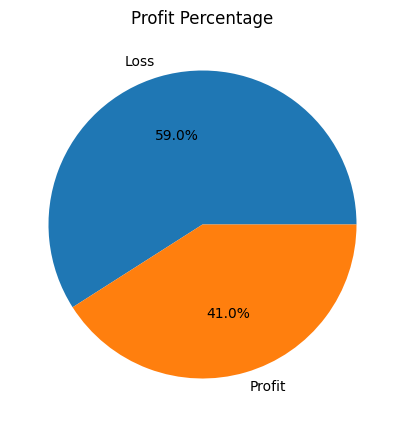

In [26]:
#Profit Flag Percentage
profit_percent = bitcoin_data["profit_flag"].value_counts(normalize=True) * 100

plt.figure(figsize=(5,5))

plt.pie(
    profit_percent.values,
    labels=["Loss", "Profit"],
    autopct="%1.1f%%"
)

plt.title("Profit Percentage")

plt.show()

# EDA Summary

## Key Findings

- The dataset contains both profitable and non-profitable trades with a fairly balanced distribution.
- Market sentiment (Fear/Greed) influences trader behavior and profitability.
- A small number of cryptocurrencies account for most trading activity.
- Trading volume varies by hour and day, indicating temporal patterns.
- Profit and loss values are unevenly distributed, with a few trades generating large profits.
- These insights provide a strong foundation for feature selection and machine learning.

In [ ]:
bitcoin_data.to_csv("eda_completed_data.csv", index=False)
print("EDA completed successfully.")